In [70]:
!pip install gymnasium


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Dados

Selecionamos como dados os valores semanais desde 1/1/2023 até hoje dos stocks das empresas Petrobras, VALE, e Marfrig Global Foods (sucessora da Brasil Foods), obitdos do site investments.com.

Para avaliação **fora da amostra**, após concatenar os CSVs **`df_train`** cobre até o último período antes do buffer de teste; **`df_test`** inclui **4 linhas semanais** vindas da mesma série (buffer de histórico para `LOOKBACK_WEEKS`) mais os últimos **~6 meses** até a última data. Os treinos de RL usam **`values_train`** (derivado de `df_train`); rollouts e plots pós‑treino usam **`values_test`**.


In [71]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path(".").resolve()

FILES = {
    "MBRF": "Marfrig Global Food Stock Price History.csv",
    "PETRO": "PETROBRAS ON Stock Price History.csv",
    "VALE": "VALE ON Stock Price History.csv",
}


def load_close_prices(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path, parse_dates=["Date"])
    df = df.sort_values("Date").set_index("Date")
    return pd.to_numeric(df["Price"].astype(str).str.replace(",", "", regex=False), errors="coerce")


series_list = []
for col_name, filename in FILES.items():
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing CSV: {path}")
    s = load_close_prices(path)
    s.name = col_name
    series_list.append(s)

stock_prices = pd.concat(series_list, axis=1)
stock_prices.index.name = "date"
stock_prices.sort_index(inplace=True)

# Holdout: últimos ~6 meses para avaliar; incluímos LOOKBACK_BUFFER_WEEKS (=4)
# linhas antes da janela de 6 meses em df_test (histórico mínimo p/ LOOKBACK_WEEKS=4).

LOOKBACK_BUFFER_WEEKS = 4
_end = stock_prices.index[-1]
_eval_start = _end - pd.DateOffset(months=6)
_pos_eval = int(stock_prices.index.searchsorted(_eval_start))
if _pos_eval >= len(stock_prices):
    _pos_eval = max(0, len(stock_prices) - 1)
_start_test = max(0, _pos_eval - LOOKBACK_BUFFER_WEEKS)

df_test = stock_prices.iloc[_start_test:].copy()
df_train = stock_prices.iloc[:_start_test].copy()
column_names = list(df_train.columns)
values_train = df_train.ffill().bfill().to_numpy(dtype=np.float32)
values_test = df_test.ffill().bfill().to_numpy(dtype=np.float32)

print(
    f"Train: {len(df_train)} linhas"
    + (
        f" (até {stock_prices.index[_start_test - 1].date()})"
        if _start_test
        else " (atenção: toda a série está em Test)"
    )
    + f" | Test: {len(df_test)} observações (= {LOOKBACK_BUFFER_WEEKS} linhas buffer + ~6 meses até {_end.date()}; "
    + f"janela de decisão efetiva a partir de {stock_prices.index[_pos_eval].date()}."
)

stock_prices.head()

Train: 143 linhas (até 2025-09-21) | Test: 31 observações (= 4 linhas buffer + ~6 meses até 2026-04-26; janela de decisão efetiva a partir de 2025-10-26.


,MBRF,PETRO,VALE
date,,,
2023-01-01,7.20,18.41,77.88
2023-01-08,7.13,18.95,79.12
2023-01-15,6.98,20.41,79.27
2023-01-22,6.84,19.77,80.39
2023-01-29,6.56,19.05,75.02


<Axes: xlabel='date'>

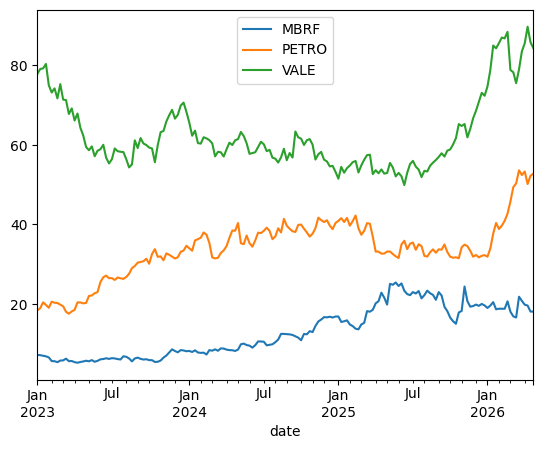

In [72]:
stock_prices.plot.line()

In [73]:
stock_prices_delta = stock_prices.pct_change().dropna()
stock_prices_delta

,MBRF,PETRO,VALE
date,,,
2023-01-08,-0.009722,0.029332,0.015922
2023-01-15,-0.021038,0.077045,0.001896
2023-01-22,-0.020057,-0.031357,0.014129
2023-01-29,-0.040936,-0.036419,-0.066799
2023-02-05,-0.140244,0.080315,-0.024260
...,...,...,...
2026-03-29,-0.047641,-0.022189,0.057595
2026-04-05,-0.046176,0.016972,0.024417
2026-04-12,-0.011094,-0.059066,0.048604


<Axes: xlabel='date'>

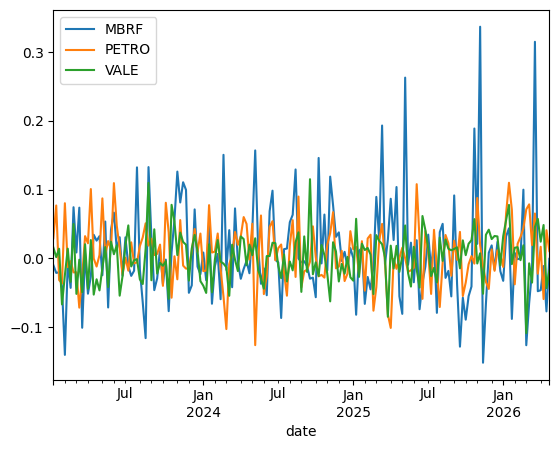

In [74]:
stock_prices_delta.plot.line()

# Simulação 
Um ponto interessante sobre essa simulação de stocks é que os valores das ações são pré-estabelecidos. Ou seja, se considerarmos apenas os preços das ações como nosso estado, **os estados independem das ações do agente** - apenas do tempo `t`. 

Podemos adicionar o valor total de dinheiro ao estado, o que faria com que a recompensa seja proporcional ao valor investido: ou seja, quanto mais alto o valor atual no estado, maior o impacto da recompensa; isso deve causar o modelo a aprender "mais" (ter ajustes de maior módulo) em simulações com mais lucro. 

# Possibilidades de definição do ambiente - estado, ações, recompensa
## Estado e features
Temos como parâmetros da simulação o valor semanal das 3 ações em cada semana `t`. Podemos usar como estado o valor completo da ação, ou, como normalização, a mudança proporcinal em relação à semana `t` anterior `Vp[t] = (Vt[t] - Vt[t-1]) / Vt[t-1]` (Vp = valor proporcional, Vt = valor total). 

Vamos iniciar com uma representação mais simples que pode nos levar a uma solução com Q-learning: podemos usar como estado o ranqueamento da mudança proporcional de cada ação; ou seja, um vetor de tamanho 3 com valores 1, 2, 3 apontando maior, segunda maior, terceira maior mudança. Isso nos leva a uma combinação de 6 estados e, instintivamente, deve resultar em uma tabela de Q-learning onde a estratégia é similar a "investir na ação que mais cresceu na última semana" (ou que pode nos surpreender!).

Posteriormente, podemos usar os valores reais das proporções, mas os valores contínuos necessitam de processamento por Deep Q Learning.

Podemos, também, adicionar o valor total do agente ao estado, tornando o impacto das ações melhor modelado na simulação. 

Vamos explorar essas 3 modelagens para os estados. 

## Ações
A maneira mais simples de modelar as ações seriam 3 opções - 100% de investimento em cada stock. Podemos adicionar complexidade colocando por exemplo distribuição 50/50 em duas ou 1/3 - 1/3 - 1/3 posteriormente. 

Para dar um valor contínuo aos investimentos (i.e 30 - 60- 10%), precisaríamos de um algoritmo diferente dos estudados em aula. 

## Recompensa
A recompensa deve ser proporcional a (ou exatamente) o lucro das operações. A maneira imediata de fazer isso é usar o valor proporcional em `Vp[t]` discutido anteriormente - um investimento x daria um retorno de `(1+VP[t]) * x` (que é negativo se o valor da ação cai). Se o valor total de investimento for parte do estado, a recompensa é multiplicada por ele. 

Podemos adicionar outras condições de contorno como preço por operação ou intolerância a perdas (i.e. multiplicar por N o valor se for negativo). 


-----
# Definição do Ambiente
Primeira iteração do ambiente onde as features são apenas em relação ao último t 

In [75]:
import numpy as np
import gymnasium as gym
from itertools import permutations
from gymnasium import spaces


class RankPermutationEncoder:
    """Map one row of weekly closes to a rank pattern (1 = highest close that week)."""

    N_STOCKS = 3

    PERMS = tuple(permutations((1, 2, 3), N_STOCKS))
    PERM_TO_ID = {p: i for i, p in enumerate(PERMS)}
    ID_TO_PERM = {i: p for i, p in enumerate(PERMS)}
    N_STATES = len(PERMS)

    @classmethod
    def ranks_from_prices(cls, prices_row) -> tuple[int, int, int]:
        row = np.asarray(prices_row, dtype=float).ravel()
        order = np.argsort(-row)
        ranks = np.empty(cls.N_STOCKS, dtype=np.int8)
        for position, stock_idx in enumerate(order):
            ranks[stock_idx] = position + 1
        return tuple(int(x) for x in ranks.tolist())

    @classmethod
    def state_index(cls, prices_row) -> int:
        return cls.PERM_TO_ID[cls.ranks_from_prices(prices_row)]


class ThreeStockEnv(gym.Env):
    """Weekly 3-asset environment — returns stacking (unchanged) or discrete rank observation.

    If "mode" == "rank", returns the rank of the 3 stocks by highest proportional increase from last week.
    If "mode" == "prop", returns the proportional increase from last week. 
    """

    def __init__(self, values, mode:str = "prop"):
        super().__init__()
        if mode not in ("rank", "prop"):
            raise ValueError ("mode should be 'rank' or 'prop'")
        self.mode = mode

        self.values = np.asarray(values, dtype=np.float32)

        # state is always the previous week for rank_perm or just returns difference for returns mode
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(RankPermutationEncoder.N_STOCKS,),
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(RankPermutationEncoder.N_STOCKS)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 1  # always start at t=1 so t-1 is valid
        return self._get_obs(), {}

    def step(self, action):
        current_prices = self.values[self.t]
        next_prices = self.values[self.t + 1]

        weekly_returns = next_prices / current_prices - 1.0
        reward = float(weekly_returns[int(action)])

        self.t += 1
        terminated = self.t >= len(self.values) - 1
        truncated = False

        info = {
            "chosen_stock": int(action),
            "weekly_returns": weekly_returns.astype(np.float64, copy=False),
            "reward": reward,
        }

        obs = self._get_obs()

        return obs, reward, terminated, truncated, info

    def _get_obs_returns(self):
        """ Feature: retorno proporcional da ação na última semana""" 
        # change to just previous and current week difference
        rets = self.values[self.t] / self.values[self.t - 1] - 1.0
        return rets.astype(np.float32, copy=False)

    def _get_obs_rank(self):
        """ Feature: rank das ações na última semana """
        rets = self.values[self.t] / self.values[self.t - 1] - 1.0
        return np.int32(RankPermutationEncoder.state_index(rets))

    def _get_obs(self):
        if self.mode == "rank":
            return self._get_obs_rank()
        else:
            return self._get_obs_returns()


In [96]:
# Plot rewards - função para plotar o retorno semanal, cumulativo, e a seleção de ações.

def plot_reward_and_cumsum(rewards, action_counts=None, action_labels=None):
    # Weekly returns, cumulative return, bar chart of action counts.
    rew = np.asarray(rewards, dtype=float)

    if action_labels is None:
        nlab = int(np.size(action_counts)) if action_counts is not None else 3
        labels = [str(i) for i in range(max(nlab, 1))]
    else:
        labels = [str(x) for x in action_labels]

    if action_counts is None:
        ac = np.zeros(len(labels), dtype=float)
    else:
        ac = np.asarray(action_counts, dtype=float).ravel()
        if ac.size < len(labels):
            ac = np.pad(ac, (0, len(labels) - ac.size))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(rew)
    axes[0].set_title("Weekly Rewards")
    axes[0].set_xlabel("Episode Step")
    axes[0].set_ylabel("Reward")
    axes[0].grid(True)

    axes[1].plot(np.cumsum(rew))
    axes[1].set_title("Cumulative Rewards")
    axes[1].set_xlabel("Episode Step")
    axes[1].set_ylabel("Cumulative Reward")
    axes[1].grid(True)

    xpos = np.arange(len(labels))
    axes[2].bar(xpos, ac[: len(labels)])
    axes[2].set_xticks(xpos)
    axes[2].set_xticklabels(labels)
    axes[2].set_title("Actions taken (counts)")
    axes[2].set_ylabel("Count")
    axes[2].set_xlabel("Stock / action")
    axes[2].grid(True, axis="y")

    plt.tight_layout()
    plt.show()



# Simulação: ação aleatória

Simulando e plotando as recompensas de uma seleção aleatória das ações. Baseline que gostaríamos de melhorar

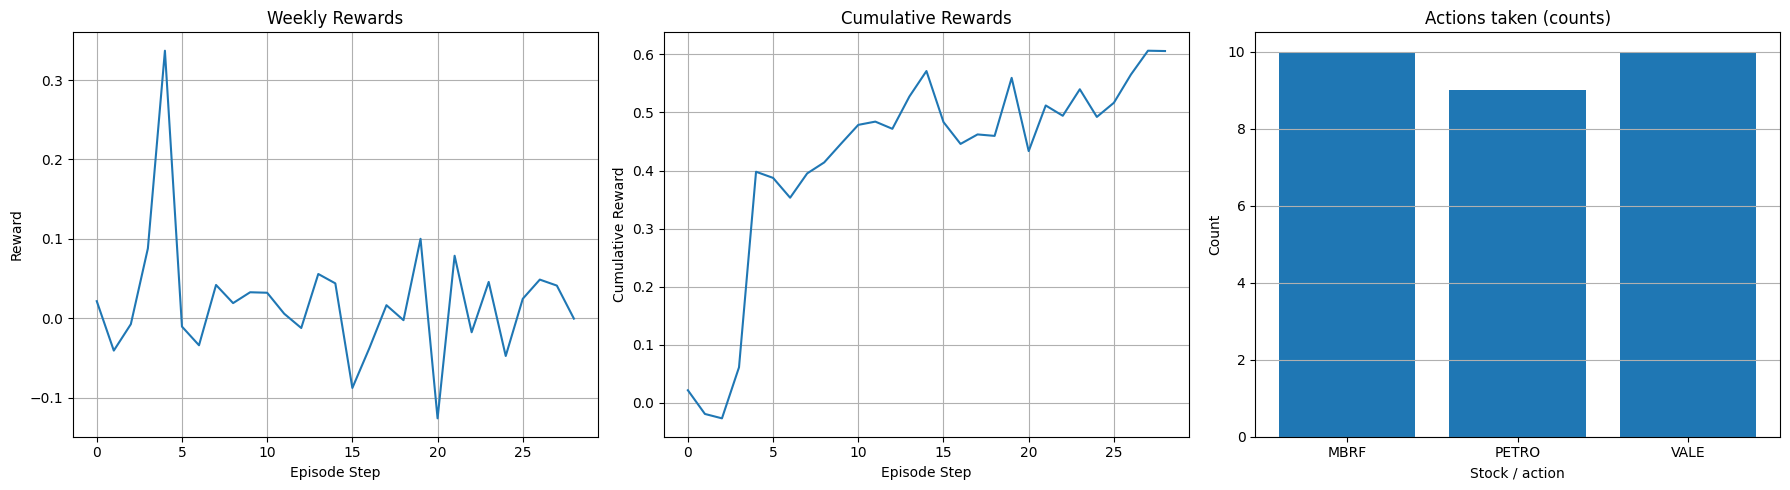

In [97]:
import numpy as np
import matplotlib.pyplot as plt

env = ThreeStockEnv(values_test)
env.reset()
rewards = []
actions_taken = []
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)
    actions_taken.append(int(action))
    done = terminated or truncated

hist = np.bincount(np.asarray(actions_taken, dtype=np.int64), minlength=len(column_names))
plot_reward_and_cumsum(rewards, action_counts=hist, action_labels=column_names)


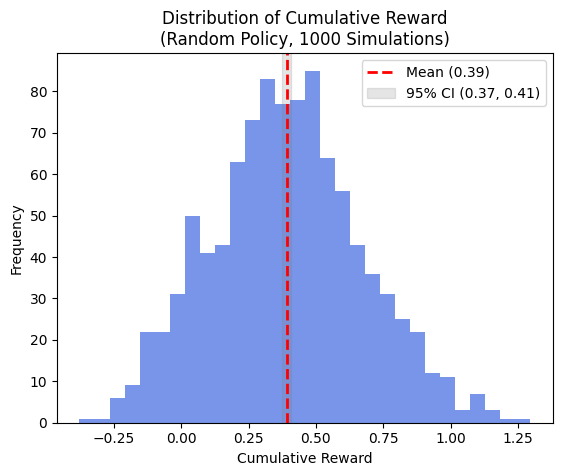

Mean: 0.39
95% confidence interval: [0.37, 0.41]


In [77]:
# Valor esperado da ação aleatória 
# Vamos executar a simulação tomando ações aleatórias 1000 vezes e computar o valor esperado ao fim do período
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

num_simulations = 1000
final_rewards = []

for _ in range(num_simulations):
    env = ThreeStockEnv(values_test)
    env.reset()
    rewards = []
    done = 0
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        rewards.append(reward)
    final_rewards.append(sum(rewards))

final_rewards = np.array(final_rewards)

mean_reward = np.mean(final_rewards)
std_reward = np.std(final_rewards, ddof=1)
conf_int = stats.t.interval(0.95, len(final_rewards)-1, loc=mean_reward, scale=std_reward/np.sqrt(len(final_rewards)))

plt.hist(final_rewards, bins=30, alpha=0.7, color='royalblue')
plt.axvline(mean_reward, color='red', linestyle='dashed', linewidth=2, label=f'Mean ({mean_reward:.2f})')
plt.axvspan(conf_int[0], conf_int[1], color='gray', alpha=0.2, label=f'95% CI ({conf_int[0]:.2f}, {conf_int[1]:.2f})')
plt.title('Distribution of Cumulative Reward\n(Random Policy, 1000 Simulations)')
plt.xlabel('Cumulative Reward')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Mean: {mean_reward:.2f}")
print(f"95% confidence interval: [{conf_int[0]:.2f}, {conf_int[1]:.2f}]")

# Simulação: policy perfeita
Implementação que vê o futuro, que representaria o melhor modelo possível: sempre investir no stock que mais aumenta na semana. 

Usamos como baseline para entender o melhor que o modelo poderia alcançar.

Cumulative reward of perfect policy: 1.94


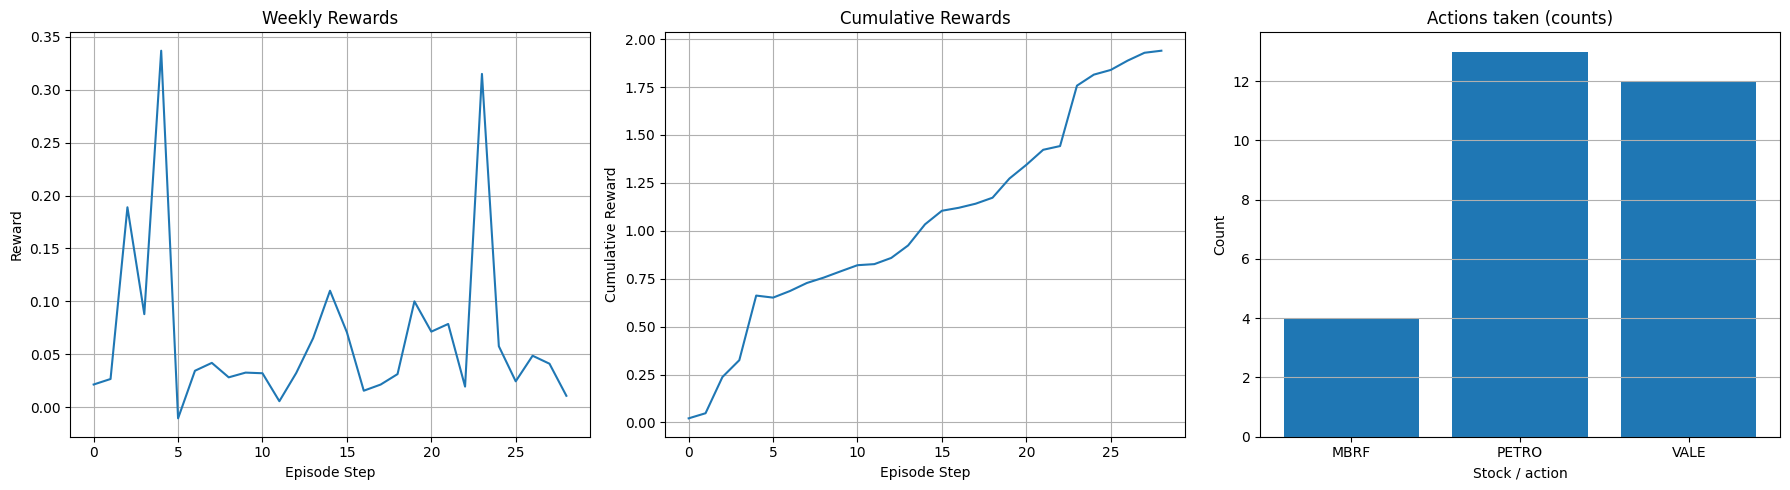

In [95]:
# "Melhor possível" - sempre investir no valor que mais aumentou 
# No caso de uma policy que vê o futuro, qual o máximo valor que alcançaríamos? 
import numpy as np
import matplotlib.pyplot as plt

# "Perfect policy" - always invest in the stock that increases the most in the NEXT step
env = ThreeStockEnv(values_test)
obs, _ = env.reset(), None
rewards_perfect = []
actions_perfect = []
done = False

while not done:
    # Peek at the returns of the next step to choose the best action
    current_step = env.t
    if current_step < len(values_test) - 1:
        # Compute next-step returns for all stocks
        prices_now = values_test[current_step]
        prices_next = values_test[current_step + 1]
        returns_next = (prices_next - prices_now) / prices_now
        # Choose the stock with the highest positive return at t+1
        best_action = np.argmax(returns_next)
    else:
        # Last step: pick any action, result does not matter
        best_action = 0
    obs, reward, terminated, truncated, info = env.step(best_action)
    rewards_perfect.append(reward)
    actions_perfect.append(best_action)
    done = terminated or truncated

# Count perfect actions
actions_perfect_hist = np.bincount(np.asarray(actions_perfect, dtype=np.int64), minlength=len(column_names))

print(f'Cumulative reward of perfect policy: {np.sum(rewards_perfect):.2f}')
plot_reward_and_cumsum(rewards_perfect, action_counts=actions_perfect_hist, action_labels=column_names)

## Q-learning (tabular) com ranking e **`ThreeStockEnv.step`**

- Estado (por agora): só **uma** semana de histórico — o padrão de ranks dos preços na semana **`t-1`** (rank 1 = maior fecho), antes de escolher onde investir para o retorno **`t` → `t+1`** (o mesmo `reward` do `step`).
- **6 estados** (`3!` permutações), ações discretas `{0,1,2}` — qual ativo segurar.
- O treino segue o ciclo explícito **`reset` → observar `s` → escolher `a` → `step` → `r`, `s'`** (sem gerador de transições separado).

*Extensão posterior:* `lookback>1` em modo rank ou outras features podem voltar a aparecer no `observation_space` quando forem implementadas.

In [78]:
import numpy as np
import pandas as pd
from collections import defaultdict

from IPython.display import display


def avg_return_over_recent_100ep_blocks(episode_totals, max_blocks: int = 5):
    # Mean of up to max_blocks trailing 100-episode total-return batches.
    n_full = len(episode_totals) // 100
    if n_full == 0:
        return None
    blocks = min(max_blocks, n_full)
    block_means = []
    offset = len(episode_totals)
    for kk in range(blocks):
        start_slot = offset - (kk + 1) * 100
        end_slot = offset - kk * 100
        block_means.append(float(np.mean(episode_totals[start_slot:end_slot])))
    return float(np.mean(block_means))


class TabularRankQLearner:
    # Epsilon-greedy tabular Q-learning using ThreeStockEnv.step rollouts.

    def __init__(
        self,
        n_actions: int,
        *,
        gamma: float = 0.95,
        alpha: float = 0.2,
        epsilon_start: float = 0.35,
        epsilon_floor: float = 0.05,
    ):
        self.n_actions = n_actions
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon_start = epsilon_start
        self.epsilon_floor = epsilon_floor
        self.Q = defaultdict(float)

    def greedy(self, state: int) -> int:
        return int(np.argmax([self.Q[state, a] for a in range(self.n_actions)]))

    def act(self, state: int, epsilon: float) -> int:
        if np.random.random() < epsilon:
            return int(np.random.randint(0, self.n_actions))
        return self.greedy(state)

    def td_update(self, s: int, a: int, r: float, s_next: int, done: bool) -> None:
        if done:
            target = r
        else:
            q_next_max = max(self.Q[s_next, j] for j in range(self.n_actions))
            target = r + self.gamma * q_next_max
        key = (s, a)
        self.Q[key] += self.alpha * (target - self.Q[key])

    def train_one_episode(self, env: ThreeStockEnv, epsilon: float) -> tuple[float, np.ndarray]:
        obs, _ = env.reset()
        total_reward = 0.0
        action_hist = np.zeros(self.n_actions, dtype=np.int64)

        while True:
            state = int(obs)
            action = self.act(state, epsilon)
            action_hist[action] += 1
            obs_next, reward, terminated, truncated, info = env.step(action)
            next_state = int(obs_next)
            done = terminated or truncated

            self.td_update(state, action, float(reward), next_state, done)

            total_reward += float(reward)

            if done:
                break
            obs = obs_next

        return total_reward, action_hist

    def fit(
        self,
        env_factory,
        *,
        episodes: int,
        epsilon_decay: float = 0.995,
        log_every: int = 100,
    ) -> "TabularRankQLearner":
        eps = float(self.epsilon_start)
        episode_totals: list[float] = []
        total_action_hist = np.zeros(self.n_actions, dtype=np.int64)

        self.training_log_episodes: list[int] = []
        self.training_log_batch_avg_returns: list[float] = []

        for episode_index in range(int(episodes)):
            env_rollout = env_factory()
            total_r, hist = self.train_one_episode(env_rollout, eps)
            episode_totals.append(total_r)
            total_action_hist += hist
            eps = max(self.epsilon_floor, eps * epsilon_decay)

            if log_every > 0 and (episode_index + 1) % log_every == 0:
                metric = avg_return_over_recent_100ep_blocks(episode_totals, max_blocks=5)
                if metric is not None:
                    ep = episode_index + 1
                    self.training_log_episodes.append(ep)
                    self.training_log_batch_avg_returns.append(metric)
                    print(
                        f"Episode {ep} - average total rewards: {metric:.3f}"
                    )

        self.fit_episode_total_rewards = episode_totals
        self.fit_total_action_counts = total_action_hist.copy()
        return self

    def rollout_greedy_eval(self, closes, *, mode: str = "rank") -> tuple[list[float], np.ndarray]:
        env = ThreeStockEnv(np.asarray(closes, dtype=np.float32), mode=mode)
        obs, _ = env.reset()
        rewards_here: list[float] = []
        counts = np.zeros(self.n_actions, dtype=np.int64)

        while True:
            action = self.greedy(int(obs))
            counts[action] += 1
            obs, reward, terminated, truncated, _info = env.step(action)
            rewards_here.append(float(reward))
            if terminated or truncated:
                break

        return rewards_here, counts

    def q_table_dataframe(self, ticker_columns: list[str]) -> pd.DataFrame:
        col_names = [f"invest {t}" for t in ticker_columns]
        frame = pd.DataFrame(
            {
                col_names[a]: [self.Q[s, a] for s in range(RankPermutationEncoder.N_STATES)]
                for a in range(self.n_actions)
            }
        )
        labels = []
        for s in range(RankPermutationEncoder.N_STATES):
            pat = RankPermutationEncoder.ID_TO_PERM[s]
            labels.append(" · ".join(f"{t}:{r}" for t, r in zip(ticker_columns, pat)))
        frame.insert(0, "ranks @ t-1", labels)
        frame.index = [f"S{s}" for s in range(RankPermutationEncoder.N_STATES)]
        return frame


# values_train / values_test / column_names — definidos na carga (split 6 meses + buffer)

np.random.seed(42)

learner = TabularRankQLearner(n_actions=3, alpha=0.18, epsilon_start=0.4, epsilon_floor=0.06).fit(
    lambda: ThreeStockEnv(values_train, mode="rank"),
    episodes=1200,
    epsilon_decay=0.997,
    log_every=100,
)

print("Trained with reset -> observe -> act -> step loop (rank state = prior week only).")
display(learner.q_table_dataframe(column_names).round(4))

for s in range(RankPermutationEncoder.N_STATES):
    row = " · ".join(f"{t}:{r}" for t, r in zip(column_names, RankPermutationEncoder.ID_TO_PERM[s]))
    print(row, "-> greedy:", column_names[learner.greedy(s)])


Episode 100 - average total rewards: 0.958
Episode 200 - average total rewards: 0.919
Episode 300 - average total rewards: 0.914
Episode 400 - average total rewards: 0.953
Episode 500 - average total rewards: 0.952
Episode 600 - average total rewards: 0.996
Episode 700 - average total rewards: 1.070
Episode 800 - average total rewards: 1.121
Episode 900 - average total rewards: 1.181
Episode 1000 - average total rewards: 1.216
Episode 1100 - average total rewards: 1.222
Episode 1200 - average total rewards: 1.211
Trained with reset -> observe -> act -> step loop (rank state = prior week only).


,ranks @ t-1,invest MBRF,invest PETRO,invest VALE
S0,MBRF:1 · PETRO:2 · VALE:3,0.0858,0.0980,0.1260
S1,MBRF:1 · PETRO:3 · VALE:2,0.1267,0.0788,0.0955
S2,MBRF:2 · PETRO:1 · VALE:3,0.0796,0.1152,0.0877
S3,MBRF:2 · PETRO:3 · VALE:1,0.0988,0.1183,0.0910
S4,MBRF:3 · PETRO:1 · VALE:2,0.0800,0.0773,0.1275
S5,MBRF:3 · PETRO:2 · VALE:1,0.0862,0.1128,0.1069


MBRF:1 · PETRO:2 · VALE:3 -> greedy: VALE
MBRF:1 · PETRO:3 · VALE:2 -> greedy: MBRF
MBRF:2 · PETRO:1 · VALE:3 -> greedy: PETRO
MBRF:2 · PETRO:3 · VALE:1 -> greedy: PETRO
MBRF:3 · PETRO:1 · VALE:2 -> greedy: VALE
MBRF:3 · PETRO:2 · VALE:1 -> greedy: PETRO


Cumulative reward of policy: 1.37


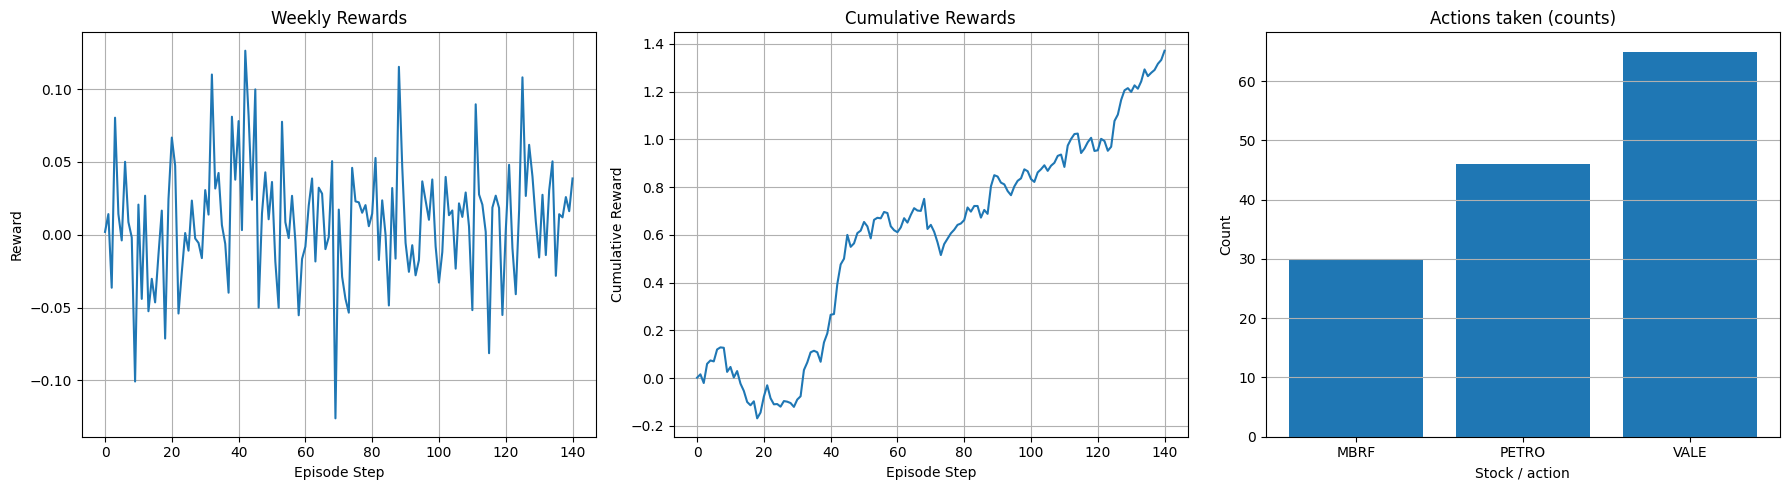

In [104]:
# Política greedy no treino (~6 meses, `values_test`)

agent_rewards_history, greedy_action_hist = learner.rollout_greedy_eval(values_train, mode="rank")
print(f'Cumulative reward of policy: {np.sum(agent_rewards_history):.2f}')

plot_reward_and_cumsum(
    agent_rewards_history,
    action_counts=greedy_action_hist,
    action_labels=column_names,
)


Cumulative reward of policy: 0.18


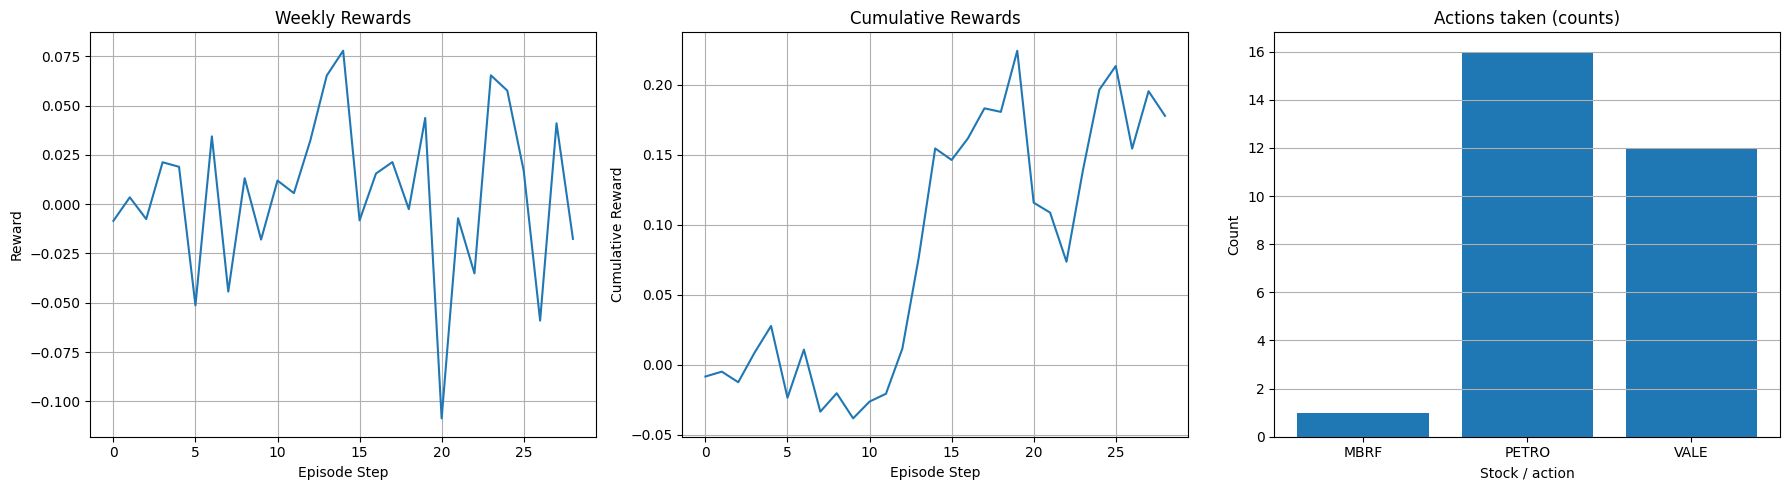

In [105]:
# Política greedy no holdout (~6 meses, `values_test`)

agent_rewards_history, greedy_action_hist = learner.rollout_greedy_eval(values_test, mode="rank")
print(f'Cumulative reward of policy: {np.sum(agent_rewards_history):.2f}')

plot_reward_and_cumsum(
    agent_rewards_history,
    action_counts=greedy_action_hist,
    action_labels=column_names,
)


### Resultados do q-learning com feature de rank
O resultado é bem similar à policy aleatória. Vamos seguir adicionando complexidade para melhorar nosso modelo. 

----

## Q-learning ranking com **lookback = 4 semanas**

Herdamos de `ThreeStockEnv` e `TabularRankQLearner`: o estado passa a ser o **empacotamento** das mesmas ordenações por retorno semanal já usadas em `mode="rank"` (efeito `{0,…,5}^4 → 1296 estados`). O `step`/`reward` continuam iguais. Depois rodamos rollout greedy e plot (mesma convenção das células anteriores).


In [83]:
import numpy as np
import gymnasium as gym

LOOKBACK_WEEKS = 4


class ThreeStockRankEnvWithHistory(ThreeStockEnv):
    """Rank-state = últimas ``lookback`` semanas de rankings por retorno (igual `mode='rank'` base).

    Para ``ell = 1 .. lookback`` (mais recente primeiro), ranqueia
    ``values[t-ell+1] / values[t-ell] - 1`` entre as 3 ações. Empacota ``lookback`` índices em ``0…5``
    num único estado ``Discrete(6**lookback)``. Recompensa = mesma de ``ThreeStockEnv.step``.
    """

    def __init__(self, values, lookback: int = LOOKBACK_WEEKS):
        lookback = int(lookback)
        if lookback < 1:
            raise ValueError("lookback must be >= 1")
        super().__init__(values, mode="rank")
        self.rank_lookback = lookback
        self.observation_space = gym.spaces.Discrete(int(RankPermutationEncoder.N_STATES**lookback))

    def reset(self, seed=None, options=None):
        gym.Env.reset(self, seed=seed)
        self.t = self.rank_lookback
        return self._get_obs(), {}

    def _packed_state_id(self) -> int:
        perm_ids = []
        for ell in range(1, self.rank_lookback + 1):
            ix_hi = self.t - ell + 1
            ix_lo = self.t - ell
            ret_vec = self.values[ix_hi] / self.values[ix_lo] - 1.0
            perm_ids.append(RankPermutationEncoder.state_index(ret_vec))
        return int(np.ravel_multi_index(tuple(perm_ids), (RankPermutationEncoder.N_STATES,) * self.rank_lookback))

    def _get_obs(self):
        return np.int32(self._packed_state_id())


class TabularRankLookbackQLearner(TabularRankQLearner):
    """Mesmo TD Q-tabular; treino/avaliação usam ``ThreeStockRankEnvWithHistory``."""

    def __init__(self, *args, lookback: int = LOOKBACK_WEEKS, **kwargs):
        super().__init__(*args, **kwargs)
        self.lookback = int(lookback)
        self.n_packed_states = int(RankPermutationEncoder.N_STATES**self.lookback)

    def rollout_greedy_eval(self, closes, *, mode: str = "rank"):  # mode ignorado aqui — compatibilidade API
        closes_f = np.asarray(closes, dtype=np.float32)
        env_ev = ThreeStockRankEnvWithHistory(closes_f, lookback=self.lookback)
        obs, _info = env_ev.reset()
        rew_path = []
        counts = np.zeros(self.n_actions, dtype=np.int64)

        while True:
            move = self.greedy(int(obs))
            counts[move] += 1
            obs, reward, terminated, truncated, meta = env_ev.step(move)
            rew_path.append(float(reward))
            if terminated or truncated:
                break

        return rew_path, counts

    def n_distinct_states_touched(self) -> int:

        distinct = {state_key for (state_key, _action_key) in self.Q.keys()}
        return len(distinct)


# Preços para RL: usar values_train no fit e values_test nos rollouts (split 6 meses + buffer)

np.random.seed(44)

learn_rank_lb = TabularRankLookbackQLearner(
    n_actions=3,
    lookback=LOOKBACK_WEEKS,
    alpha=0.14,
    epsilon_start=0.45,
    epsilon_floor=0.05,
).fit(
    lambda: ThreeStockRankEnvWithHistory(values_train, lookback=LOOKBACK_WEEKS),
    episodes=2500,
    epsilon_decay=0.9975,
    log_every=100,
)

print(
    f"Lookback={LOOKBACK_WEEKS} · estados teóricos = {learn_rank_lb.n_packed_states} · "
    f"estados visitados com Q não-trivial ≈ {learn_rank_lb.n_distinct_states_touched()}"
)


Episode 100 - average total rewards: 3.408
Episode 200 - average total rewards: 3.631
Episode 300 - average total rewards: 3.834
Episode 400 - average total rewards: 3.985
Episode 500 - average total rewards: 4.128
Episode 600 - average total rewards: 4.439
Episode 700 - average total rewards: 4.687
Episode 800 - average total rewards: 4.883
Episode 900 - average total rewards: 5.053
Episode 1000 - average total rewards: 5.180
Episode 1100 - average total rewards: 5.248
Episode 1200 - average total rewards: 5.277
Episode 1300 - average total rewards: 5.282
Episode 1400 - average total rewards: 5.268
Episode 1500 - average total rewards: 5.243
Episode 1600 - average total rewards: 5.234
Episode 1700 - average total rewards: 5.246
Episode 1800 - average total rewards: 5.267
Episode 1900 - average total rewards: 5.296
Episode 2000 - average total rewards: 5.322
Episode 2100 - average total rewards: 5.333
Episode 2200 - average total rewards: 5.327
Episode 2300 - average total rewards: 5.3

Cumulative reward of policy: 5.58


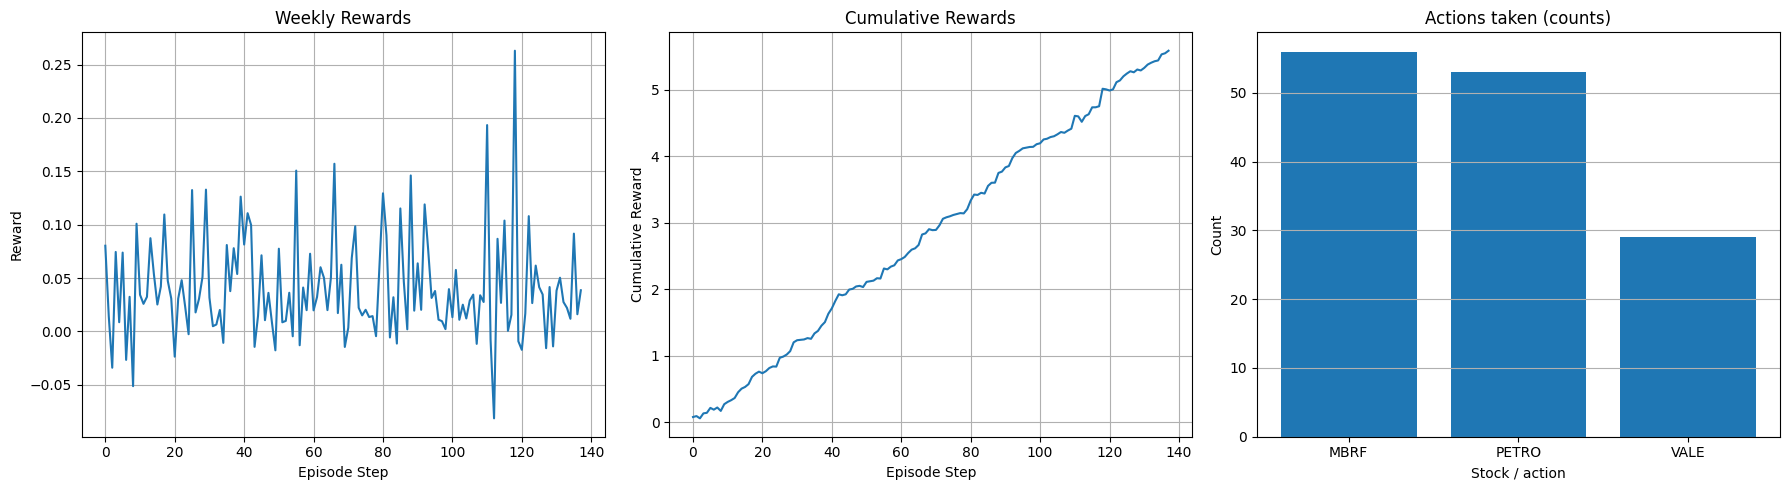

In [108]:

weekly_rewards_lb, lb_action_hist = learn_rank_lb.rollout_greedy_eval(values_train)
print(f'Cumulative reward of policy: {np.sum(weekly_rewards_lb):.2f}')

plot_reward_and_cumsum(
    weekly_rewards_lb,
    action_counts=lb_action_hist,
    action_labels=column_names,
)


Cumulative reward of policy: 0.14


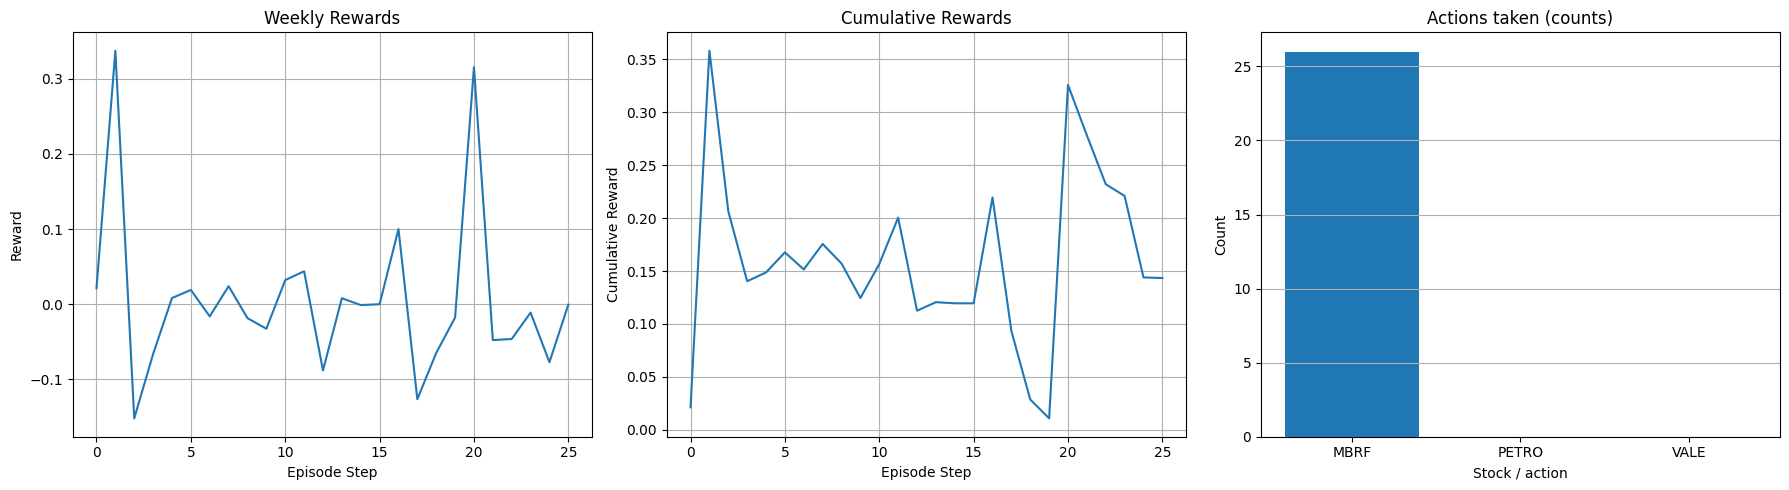

In [109]:

weekly_rewards_lb, lb_action_hist = learn_rank_lb.rollout_greedy_eval(values_test)
print(f'Cumulative reward of policy: {np.sum(weekly_rewards_lb):.2f}')

plot_reward_and_cumsum(
    weekly_rewards_lb,
    action_counts=lb_action_hist,
    action_labels=column_names,
)


### Resultados do modelo q-learning com rank e lookback=4 semanas

Podemos ver uma melhora significativa do resultado na base de treino, com aumentos positivos em quase toda semana de investimento! Os dados adicionais aumentaram muito a capacidade de aprendizagem do modelo.

No entanto, o modelo não consegue extrapolar bem, e na base de teste, teve performance pior a abordagem aleatória média. 

-----
# Deep Q Learning

Agora, para usar os valores reais da mudança proporcional dos stocks, vamos aplicar um modelo de deep-q-learning. Conforme o que já estabelecemos, vamos usar as últimas 4 semanas de valores como entrada para o modelo.

Implementação seguinte: **DQN** (buffer de replay + rede-alvo) com MLP PyTorch de duas camadas ocultas sobre o vetor de retornos proporcionais semanais concatenados (`LOOKBACK_WEEKS`).


In [87]:
import random
from collections import deque

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Detect device for GPU usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class QNetwork(nn.Module):
    # MLP: duas camadas ocultas (Linear→ReLU×2 + cabeça Q por ação).

    def __init__(self, n_features: int, n_actions: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )
        self.to(device)  # Ensure network is moved to the correct device

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.to(device)
        return self.net(x)
 

In [88]:


if "LOOKBACK_WEEKS" not in globals():
    LOOKBACK_WEEKS = 4

# Estado: concat das últimas LOOKBACK_WEEKS semanas de retornos proporcionais semanais
# (p[t]/p[t-1]-1 por ação); semana mais recente primeiro.


class ThreeStockPropLookbackEnv(ThreeStockEnv):
    # Observação R^{lookback * 3}; recompensa = retorno proporcional da ação (mesmo step do pai).

    def __init__(self, values, lookback: int = LOOKBACK_WEEKS):
        self.lookback = int(lookback)
        if self.lookback < 1:
            raise ValueError("lookback must be >= 1")
        super().__init__(values, mode="prop")
        n_feat = self.lookback * RankPermutationEncoder.N_STOCKS
        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(n_feat,),
            dtype=np.float32,
        )

    def reset(self, seed=None, options=None):
        gym.Env.reset(self, seed=seed)
        self.t = self.lookback
        return self._get_obs(), {}

    def _get_obs(self):
        blocks = []
        for ell in range(1, self.lookback + 1):
            ix_hi = self.t - ell + 1
            ix_lo = self.t - ell
            rets = self.values[ix_hi] / self.values[ix_lo] - 1.0
            blocks.append(rets.astype(np.float32, copy=False))
        return np.concatenate(blocks, axis=0)



class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buf = deque(maxlen=int(capacity))

    def push(self, s, a, r, s_next, done: bool) -> None:
        self.buf.append(
            (
                np.asarray(s, dtype=np.float32),
                int(a),
                float(r),
                np.asarray(s_next, dtype=np.float32),
                bool(done),
            )
        )

    def __len__(self) -> int:
        return len(self.buf)

    def sample(self, batch_size: int, device: torch.device):
        batch = random.sample(self.buf, batch_size)
        s = torch.tensor(np.stack([b[0] for b in batch]), dtype=torch.float32, device=device)
        a = torch.tensor([b[1] for b in batch], dtype=torch.int64, device=device).unsqueeze(1)
        r = torch.tensor([b[2] for b in batch], dtype=torch.float32, device=device)
        sp = torch.tensor(np.stack([b[3] for b in batch]), dtype=torch.float32, device=device)
        d = torch.tensor([b[4] for b in batch], dtype=torch.float32, device=device)
        return s, a, r, sp, d


class PropDeepQLearner:
    def __init__(
        self,
        n_actions: int,
        state_dim: int,
        *,
        gamma: float = 0.95,
        lr: float = 5e-4,
        hidden: int = 64,
        epsilon_start: float = 0.4,
        epsilon_floor: float = 0.06,
        buffer_size: int = 25_000,
        batch_size: int = 64,
        target_sync_every: int = 200,
        device: str | None = None,
    ):
        self.n_actions = n_actions
        self.state_dim = state_dim
        self.gamma = gamma
        self.lr = lr
        self.epsilon_start = epsilon_start
        self.epsilon_floor = epsilon_floor
        self.buffer_size = buffer_size
        self.batch_size = batch_size
        self.target_sync_every = target_sync_every
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))

        self.policy = QNetwork(state_dim, n_actions, hidden=hidden).to(self.device)
        self.target = QNetwork(state_dim, n_actions, hidden=hidden).to(self.device)
        self.target.load_state_dict(self.policy.state_dict())
        self.target.eval()

        self.optimizer = torch.optim.Adam(self.policy.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)
        self.learn_steps = 0

    def act(self, obs: np.ndarray, epsilon: float) -> int:
        if random.random() < epsilon:
            return int(random.randrange(self.n_actions))
        with torch.no_grad():
            x = torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
            return int(self.policy(x).argmax(dim=1).item())

    def _optimize(self) -> None:
        if len(self.buffer) < self.batch_size:
            return
        s, a, r, sp, d = self.buffer.sample(self.batch_size, self.device)
        with torch.no_grad():
            q_next = self.target(sp).max(dim=1).values
            target = r + self.gamma * q_next * (1.0 - d)
        q_sa = self.policy(s).gather(1, a).squeeze(1)
        loss = F.mse_loss(q_sa, target)

        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=5.0)
        self.optimizer.step()

        self.learn_steps += 1
        if self.learn_steps % self.target_sync_every == 0:
            self.target.load_state_dict(self.policy.state_dict())

    def train_one_episode(self, env: ThreeStockPropLookbackEnv, epsilon: float) -> tuple[float, np.ndarray]:
        obs, _ = env.reset()
        total_reward = 0.0
        counts = np.zeros(self.n_actions, dtype=np.int64)

        while True:
            action = self.act(obs, epsilon)
            counts[action] += 1
            obs_next, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            self.buffer.push(obs, action, float(reward), obs_next, done)
            self._optimize()

            total_reward += float(reward)
            if done:
                break
            obs = obs_next

        return total_reward, counts

    def fit(
        self,
        env_factory,
        *,
        episodes: int,
        epsilon_decay: float = 0.997,
        log_every: int = 100,
    ) -> "PropDeepQLearner":
        eps = float(self.epsilon_start)
        episode_totals: list[float] = []
        total_action_hist = np.zeros(self.n_actions, dtype=np.int64)

        self.training_log_episodes: list[int] = []
        self.training_log_batch_avg_returns: list[float] = []

        for episode_index in range(int(episodes)):
            env_rollout = env_factory()
            total_r, hist = self.train_one_episode(env_rollout, eps)
            episode_totals.append(total_r)
            total_action_hist += hist
            eps = max(self.epsilon_floor, eps * epsilon_decay)

            if log_every > 0 and (episode_index + 1) % log_every == 0:
                metric = avg_return_over_recent_100ep_blocks(episode_totals, max_blocks=5)
                if metric is not None:
                    ep = episode_index + 1
                    self.training_log_episodes.append(ep)
                    self.training_log_batch_avg_returns.append(metric)
                    print(f"Episode {ep} - average total rewards: {metric:.3f}")

        self.fit_episode_total_rewards = episode_totals
        self.fit_total_action_counts = total_action_hist.copy()
        return self

    def rollout_greedy_eval(self, closes) -> tuple[list[float], np.ndarray]:
        closes_f = np.asarray(closes, dtype=np.float32)
        env_ev = ThreeStockPropLookbackEnv(closes_f, lookback=LOOKBACK_WEEKS)
        obs, _info = env_ev.reset()
        rewards_here: list[float] = []
        counts = np.zeros(self.n_actions, dtype=np.int64)

        while True:
            with torch.no_grad():
                x = torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
                move = int(self.policy(x).argmax(dim=1).item())
            counts[move] += 1
            obs, reward, terminated, truncated, _meta = env_ev.step(move)
            rewards_here.append(float(reward))
            if terminated or truncated:
                break

        return rewards_here, counts


dims = LOOKBACK_WEEKS * RankPermutationEncoder.N_STOCKS

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

dqn_agent = PropDeepQLearner(
    n_actions=RankPermutationEncoder.N_STOCKS,
    state_dim=dims,
).fit(
    lambda: ThreeStockPropLookbackEnv(values_train, lookback=LOOKBACK_WEEKS),
    episodes=3500,
    epsilon_decay=0.997,
    log_every=100,
)

print(
    "DQN proporcional:",
    LOOKBACK_WEEKS,
    "semanas de retornos x",
    RankPermutationEncoder.N_STOCKS,
    "ações → vetor estado",
    dims,
)



Episode 100 - average total rewards: 2.954
Episode 200 - average total rewards: 3.647
Episode 300 - average total rewards: 4.114
Episode 400 - average total rewards: 4.386
Episode 500 - average total rewards: 4.591
Episode 600 - average total rewards: 5.110
Episode 700 - average total rewards: 5.382
Episode 800 - average total rewards: 5.502
Episode 900 - average total rewards: 5.601
Episode 1000 - average total rewards: 5.657
Episode 1100 - average total rewards: 5.688
Episode 1200 - average total rewards: 5.683
Episode 1300 - average total rewards: 5.686
Episode 1400 - average total rewards: 5.680
Episode 1500 - average total rewards: 5.672
Episode 1600 - average total rewards: 5.666
Episode 1700 - average total rewards: 5.674
Episode 1800 - average total rewards: 5.682
Episode 1900 - average total rewards: 5.676
Episode 2000 - average total rewards: 5.678
Episode 2100 - average total rewards: 5.681
Episode 2200 - average total rewards: 5.676
Episode 2300 - average total rewards: 5.6

Cumulative reward of policy: 6.01


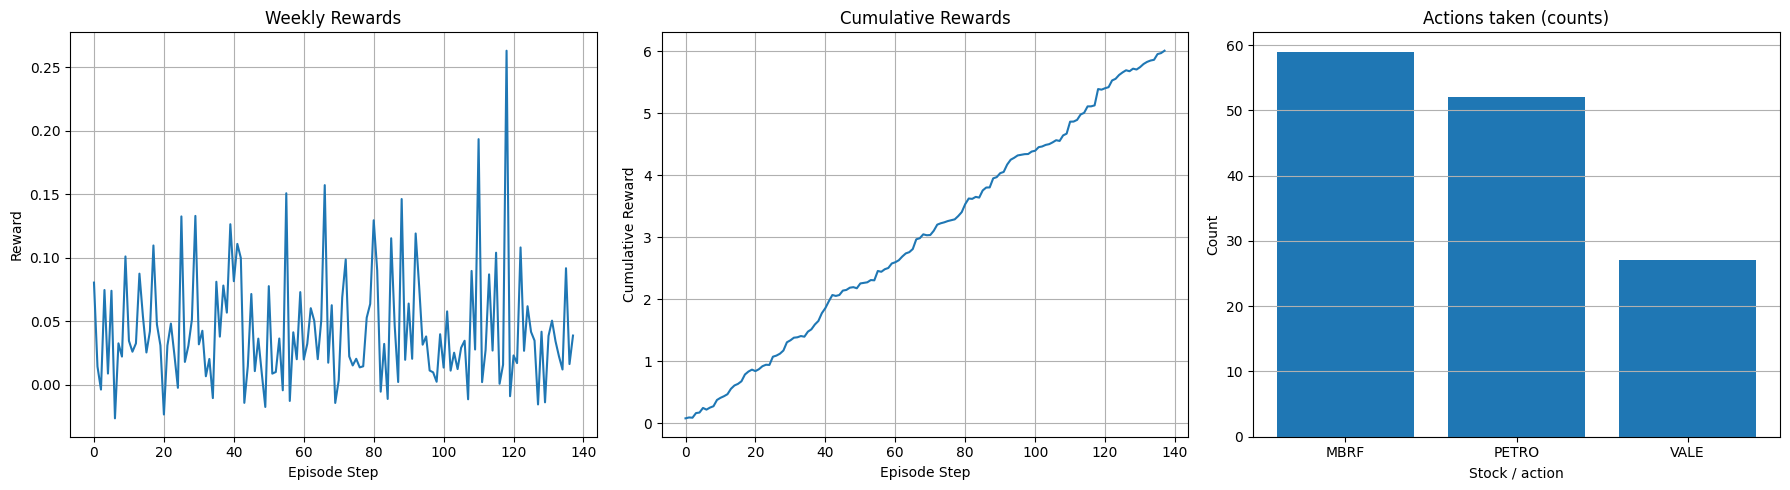

In [110]:
# Rollout greedy pós-DQN — treino

weekly_rewards_dqn, greedy_action_hist_dqn = dqn_agent.rollout_greedy_eval(values_train)
print(f'Cumulative reward of policy: {np.sum(weekly_rewards_dqn):.2f}')

plot_reward_and_cumsum(
    weekly_rewards_dqn,
    action_counts=greedy_action_hist_dqn,
    action_labels=column_names,
)


Cumulative reward of policy: 0.51


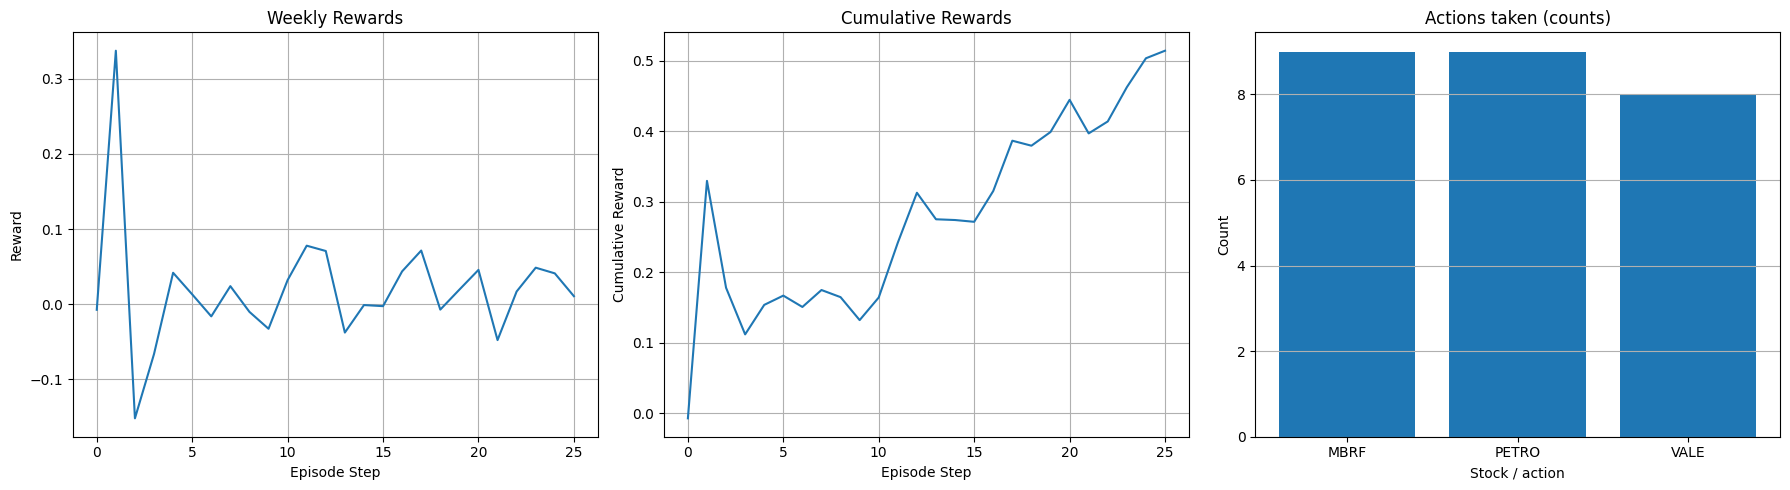

In [111]:
# Rollout greedy pós-DQN — holdout (~6 meses, `values_test`)

weekly_rewards_dqn, greedy_action_hist_dqn = dqn_agent.rollout_greedy_eval(values_test)
print(f'Cumulative reward of policy: {np.sum(weekly_rewards_dqn):.2f}')

plot_reward_and_cumsum(
    weekly_rewards_dqn,
    action_counts=greedy_action_hist_dqn,
    action_labels=column_names,
)


# Resultados com deep Q learning
Podemos observar que a performance na base de treino é marginalmente melhor que com a estratégia anterior, mas que o modelo extrapola melhor - e acaba ligeiramente melhor que a abordagem aleatória. 